In [1]:
import numpy as np
import pandas as pd

# Loading datasets

## Loading dataset with no filters applied

### Backend

In [2]:

backend_no_filter_df = pd.read_csv("metrics_no_filt/backend_metrics.csv")
backend_no_filter_df["Scenario"] = "No filter"
backend_no_filter_df = backend_no_filter_df.drop(columns=['RequestNo','StatusCode'])

In [3]:
backend_no_filter_df.head()

,Timestamp,API,LoadingType,Method,Endpoint,ResponseTime(ms),ResponseSize(Bytes),Scenario
0,2026-08-15T20:19:14.927Z,REST,Eager,POST,/fetchMovies,311.08,3316012,No filter
1,2026-08-15T20:19:54.606Z,REST,Eager,POST,/fetchMovies,308.22,3316012,No filter
2,2026-08-15T20:20:33.180Z,REST,Eager,POST,/fetchMovies,323.44,3316012,No filter
3,2026-08-15T20:21:12.073Z,REST,Eager,POST,/fetchMovies,320.24,3316012,No filter
4,2026-08-15T20:21:49.289Z,REST,Eager,POST,/fetchMovies,314.46,3316012,No filter


### Frontend

In [4]:
frontend_no_filter_df = pd.read_csv("metrics_no_filt/frontend_metrics.csv")
frontend_no_filter_df["Scenario"] = "No filter"
frontend_no_filter_df = frontend_no_filter_df.drop(columns=['RequestNo'])

In [5]:
frontend_no_filter_df.head()

,Timestamp,API,LoadingType,FCP(ms),LCP(ms),Scenario
0,2026-08-15T20:19:24.410Z,REST,Eager,40.0,1656.0,No filter
1,2026-08-15T20:20:06.995Z,REST,Eager,16.0,1468.0,No filter
2,2026-08-15T20:20:45.871Z,REST,Eager,32.0,1476.0,No filter
3,2026-08-15T20:21:21.450Z,REST,Eager,28.0,1636.0,No filter
4,2026-08-15T20:21:56.088Z,REST,Eager,28.0,1628.0,No filter


## Loading dataset with Drama filter applied

### Backend

In [6]:

backend_drama_filter_df = pd.read_csv("metrics_Drama_filter/backend_metrics.csv")
backend_drama_filter_df["Scenario"] = "Drama filter"
backend_drama_filter_df = backend_drama_filter_df.drop(columns=['RequestNo','StatusCode'])

### Frontend

In [7]:
frontend_drama_filter_df = pd.read_csv("metrics_Drama_filter/frontend_metrics.csv")
frontend_drama_filter_df["Scenario"] = "Drama filter"
frontend_drama_filter_df = frontend_drama_filter_df.drop(columns=['RequestNo'])

## Loading dataset with Animation + Cast filter applied

### Backend

In [8]:
backend_animation_cast_filter_df = pd.read_csv("metrics_anim+cast/backend_metrics.csv")
backend_animation_cast_filter_df["Scenario"] = "Animation + Cast filter"
backend_animation_cast_filter_df = backend_animation_cast_filter_df.drop(columns=['RequestNo','StatusCode'])

### Frontend

In [9]:
frontend_animation_cast_filter_df = pd.read_csv("metrics_anim+cast/frontend_metrics.csv")
frontend_animation_cast_filter_df["Scenario"] = "Animation + Cast filter"
frontend_animation_cast_filter_df = frontend_animation_cast_filter_df.drop(columns=['RequestNo'])

## Loading dataset with Genre+Director+Cast filter applied

### Backend

In [10]:
backend_genre_director_cast_filter_df = pd.read_csv("metrics_combi_filter/backend_metrics.csv")
backend_genre_director_cast_filter_df["Scenario"] = "Genre+Director+Cast filter"
backend_genre_director_cast_filter_df = backend_genre_director_cast_filter_df.drop(columns=['RequestNo','StatusCode'])

### Frontend

In [11]:
frontend_genre_director_cast_filter_df = pd.read_csv("metrics_combi_filter/frontend_metrics.csv")
frontend_genre_director_cast_filter_df["Scenario"] = "Genre+Director+Cast filter"
frontend_genre_director_cast_filter_df = frontend_genre_director_cast_filter_df.drop(columns=['RequestNo'])

# Appending all backend datasets

In [12]:
backend_df = pd.concat([backend_no_filter_df,
                        backend_drama_filter_df,
                        backend_animation_cast_filter_df,
                        backend_genre_director_cast_filter_df], ignore_index=True)

backend_df.columns = backend_df.columns.str.strip()

In [13]:
backend_df['Scenario'].unique()

array(['No filter', 'Drama filter', 'Animation + Cast filter',
       'Genre+Director+Cast filter'], dtype=object)

# Appending all frontend datasets

In [14]:
frontend_df = pd.concat([frontend_no_filter_df,
                        frontend_drama_filter_df,
                        frontend_animation_cast_filter_df,
                        frontend_genre_director_cast_filter_df], ignore_index=True)

frontend_df.columns = frontend_df.columns.str.strip()

# Finding the outliers

In [15]:
def flag_outliers(df, column):
    groups = ["Scenario", "API", "LoadingType"]

    q1 = df.groupby(groups)[column].transform("quantile", 0.25)
    q3 = df.groupby(groups)[column].transform("quantile", 0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return (df[column] < lower) | (df[column] > upper)


frontend_df["FCP_outlier"] = flag_outliers(frontend_df, "FCP(ms)")
frontend_df["LCP_outlier"] = flag_outliers(frontend_df, "LCP(ms)")
backend_df["ResponseTime_outlier"] = flag_outliers(backend_df, "ResponseTime(ms)")

In [16]:
print("FCP outliers:")
display(frontend_df[frontend_df["FCP_outlier"]][
    ["Scenario", "API", "LoadingType", "Timestamp", "FCP(ms)", "LCP(ms)"]
])

print("\nLCP outliers:")
display(frontend_df[frontend_df["LCP_outlier"]][
    ["Scenario", "API", "LoadingType", "Timestamp", "FCP(ms)", "LCP(ms)"]
])

print("\nResponse Time outliers:")
display(backend_df[backend_df["ResponseTime_outlier"]][
    ["Scenario", "API", "LoadingType", "Timestamp", "ResponseTime(ms)"]
])

FCP outliers:


,Scenario,API,LoadingType,Timestamp,FCP(ms),LCP(ms)
36,No filter,GraphQL,Eager,2026-08-15T20:43:19.075Z,16.0,1708.0
39,No filter,GraphQL,Eager,2026-08-15T20:46:54.777Z,20.0,1560.0
42,No filter,GraphQL,Eager,2026-08-15T20:48:56.565Z,20.0,1564.0
44,No filter,GraphQL,Eager,2026-08-15T20:51:46.509Z,16.0,1540.0
53,No filter,GraphQL,Eager,2026-08-15T20:57:41.788Z,16.0,1548.0
452,Genre+Director+Cast filter,GraphQL,Lazy,2026-08-15T21:37:11.984Z,44.0,148.0



LCP outliers:


,Scenario,API,LoadingType,Timestamp,FCP(ms),LCP(ms)
34,No filter,GraphQL,Eager,2026-08-15T20:42:03.179Z,32.0,1532.0
36,No filter,GraphQL,Eager,2026-08-15T20:43:19.075Z,16.0,1708.0
38,No filter,GraphQL,Eager,2026-08-15T20:44:41.167Z,32.0,1576.0
117,Drama filter,REST,Eager,2026-08-16T09:24:08.239Z,44.0,1420.0
125,Drama filter,REST,Eager,2026-08-16T09:34:32.599Z,20.0,3916.0
152,Drama filter,GraphQL,Eager,2026-08-16T10:00:35.222Z,20.0,1528.0
157,Drama filter,GraphQL,Eager,2026-08-16T10:05:45.946Z,28.0,1408.0
175,Drama filter,REST,Lazy,2026-08-16T10:37:50.397Z,32.0,64.0
176,Drama filter,REST,Lazy,2026-08-16T10:37:55.713Z,20.0,68.0
179,Drama filter,REST,Lazy,2026-08-16T10:38:15.014Z,20.0,3408.0



Response Time outliers:


,Scenario,API,LoadingType,Timestamp,ResponseTime(ms)
7,No filter,REST,Eager,2026-08-15T20:23:49.910Z,472.86
20,No filter,REST,Eager,2026-08-15T20:32:16.130Z,341.13
87,No filter,REST,Lazy,2026-08-15T21:09:54.109Z,45.14
91,No filter,GraphQL,Lazy,2026-08-15T21:11:40.878Z,49.67
113,No filter,GraphQL,Lazy,2026-08-15T21:13:39.440Z,45.06
150,Drama filter,GraphQL,Eager,2026-08-16T09:52:15.491Z,296.85
165,Drama filter,GraphQL,Eager,2026-08-16T10:02:33.235Z,298.97
172,Drama filter,GraphQL,Eager,2026-08-16T10:08:22.306Z,320.61
211,Drama filter,GraphQL,Lazy,2026-08-16T10:41:30.817Z,39.92
224,Drama filter,GraphQL,Lazy,2026-08-16T10:42:44.312Z,40.05


# Removing outliers and creating a clean copy for further downstream analysis

In [17]:
clean_backend_df = backend_df[~backend_df["ResponseTime_outlier"]].copy()
clean_frontend_df = frontend_df[~(frontend_df["FCP_outlier"] | frontend_df["LCP_outlier"])].copy()

print(f"Backend: {len(backend_df)} raw -> {len(clean_backend_df)} after outlier removal")
print(f"Frontend: {len(frontend_df)} raw -> {len(clean_frontend_df)} after outlier removal")

Backend: 480 raw -> 451 after outlier removal
Frontend: 468 raw -> 438 after outlier removal


# Statistical Analysis

In [18]:
def stats(df, column):
    return df.groupby(["Scenario", 
                       "API", 
                       "LoadingType"])[column].agg(mean="mean",
                                                   std="std",
                                                   median="median").round(2)

response_time_summary = stats(clean_backend_df, "ResponseTime(ms)")
response_size_summary = stats(clean_backend_df, "ResponseSize(Bytes)")
fcp_summary = stats(clean_frontend_df, "FCP(ms)")
lcp_summary = stats(clean_frontend_df, "LCP(ms)")

In [19]:

print("Response Time (ms):")
display(response_time_summary)

Response Time (ms):


mean   std  median
Scenario                   API     LoadingType                      
Animation + Cast filter    GraphQL Eager         28.06  0.94   28.32
                                   Lazy          25.18  1.90   25.63
                           REST    Eager         24.27  1.70   24.81
                                   Lazy          23.76  1.54   23.85
Drama filter               GraphQL Eager        309.52  3.46  308.79
                                   Lazy          45.30  1.13   45.49
                           REST    Eager        244.48  6.90  245.26
                                   Lazy          42.54  2.69   42.92
Genre+Director+Cast filter GraphQL Eager         14.79  1.24   14.68
                                   Lazy          12.83  1.92   12.51
                           REST    Eager         13.02  1.25   13.18
                                   Lazy          13.10  0.98   13.21
No filter                  GraphQL Eager        384.79  4.78  385.61
                                   Lazy          57.74  1.75   57.67
                           REST    Eager        317.06  4.01  316.23
                                   Lazy          56.96  1.58   57.09

In [20]:
print("Response Size (Bytes):")
display(response_size_summary)

Response Size (Bytes):


mean  std     median
Scenario                   API     LoadingType                           
Animation + Cast filter    GraphQL Eager          25672.0  0.0    25672.0
                                   Lazy            4389.0  0.0     4389.0
                           REST    Eager          25917.0  0.0    25917.0
                                   Lazy            4410.0  0.0     4410.0
Drama filter               GraphQL Eager        3242800.0  0.0  3242800.0
                                   Lazy            4354.0  0.0     4354.0
                           REST    Eager        3275605.0  0.0  3275605.0
                                   Lazy            4377.0  0.0     4377.0
Genre+Director+Cast filter GraphQL Eager           6112.0  0.0     6112.0
                                   Lazy            4370.0  0.0     4370.0
                           REST    Eager           6151.0  0.0     6151.0
                                   Lazy            4391.0  0.0     4391.0
No filter                  GraphQL Eager        3283035.0  0.0  3283035.0
                                   Lazy            4263.0  0.0     4263.0
                           REST    Eager        3316012.0  0.0  3316012.0
                                   Lazy            4286.0  0.0     4286.0

In [21]:
print("First Contentful Paint (ms):")
display(fcp_summary)

First Contentful Paint (ms):


mean   std  median
Scenario                   API     LoadingType                     
Animation + Cast filter    GraphQL Eager        26.53  6.68    28.0
                                   Lazy         23.33  6.22    20.0
                           REST    Eager        22.34  5.71    20.0
                                   Lazy         24.27  7.27    20.0
Drama filter               GraphQL Eager        25.08  6.55    26.0
                                   Lazy         24.29  6.43    20.0
                           REST    Eager        22.29  6.52    20.0
                                   Lazy         22.26  5.09    20.0
Genre+Director+Cast filter GraphQL Eager        23.31  6.33    20.0
                                   Lazy         26.15  5.33    24.0
                           REST    Eager        24.53  6.62    20.0
                                   Lazy         24.62  6.57    24.0
No filter                  GraphQL Eager        30.00  2.43    32.0
                                   Lazy         24.40  6.42    28.0
                           REST    Eager        26.13  6.70    28.0
                                   Lazy         24.67  6.22    20.0

In [22]:
print("Largest Contentful Paint (ms):")
display(lcp_summary)

Largest Contentful Paint (ms):


mean     std  median
Scenario                   API     LoadingType                         
Animation + Cast filter    GraphQL Eager          60.40    3.98    60.0
                                   Lazy           56.67    6.57    52.0
                           REST    Eager          54.34    2.93    56.0
                                   Lazy           56.27    6.38    52.0
Drama filter               GraphQL Eager        1387.69    7.24  1388.0
                                   Lazy          268.00  219.16   164.0
                           REST    Eager        1318.67    8.13  1320.0
                                   Lazy          154.43   10.70   148.0
Genre+Director+Cast filter GraphQL Eager         125.24   10.80   128.0
                                   Lazy          132.62   10.23   132.0
                           REST    Eager         123.60   12.44   116.0
                                   Lazy          132.77   12.13   132.0
No filter                  GraphQL Eager        1554.20    7.28  1554.0
                                   Lazy          120.67   45.04    94.0
                           REST    Eager        1534.53   91.25  1478.0
                                   Lazy          143.60   46.03   164.0

# Hyposthesis Testing

Independent-samples comparisons for the `Animation + Cast filter` scenario (clean and complete data).

Each of the four literature-survey hypotheses maps onto one 2×2 quadrant (API × LoadingType). Each quadrant gets its own cell — compute the comparison relevant to that quadrant's hypothesis, then read the verdict rendered directly beneath the output.

In [23]:
from scipy import stats

PRIMARY_SCENARIO = "Animation + Cast filter"

def welch_test(df, value_col, group_col, group_a, group_b, **filters):

    # Apply filters
    for column in filters:
        df = df[df[column] == filters[column]]

    # Get values for each group
    group_a_values = df[df[group_col] == group_a][value_col].dropna()
    group_b_values = df[df[group_col] == group_b][value_col].dropna()

    # Welch's t-test
    t_stat, p_value = stats.ttest_ind(
        group_a_values,
        group_b_values,
        equal_var=False
    )

    # Cohen's d
    pooled_std = np.sqrt(
        (group_a_values.std() ** 2 + group_b_values.std() ** 2) / 2
    )

    if pooled_std == 0:
        cohens_d = np.nan
    else:
        cohens_d = (
            group_a_values.mean() - group_b_values.mean()
        ) / pooled_std

    return pd.Series({
        f"n_{group_a}": len(group_a_values),
        f"n_{group_b}": len(group_b_values),
        f"mean_{group_a}": group_a_values.mean(),
        f"mean_{group_b}": group_b_values.mean(),
        "t_stat": t_stat,
        "p_value": p_value,
        "cohens_d": cohens_d,
        "significant_at_0.05": p_value < 0.05
    })

### Quadrant 1 — REST + Lazy (H1)

**H1:** REST + Lazy → faster initial rendering (lower LCP) than REST + Eager.

In [24]:
row = welch_test(
    clean_frontend_df[clean_frontend_df["Scenario"] == PRIMARY_SCENARIO],
    "LCP(ms)", "LoadingType", "Eager", "Lazy", API="REST",
)
row = pd.DataFrame([row])
row.round(3)


,n_Eager,n_Lazy,mean_Eager,mean_Lazy,t_stat,p_value,cohens_d,significant_at_0.05
0,29,30,54.345,56.267,-1.494,0.143,-0.387,False


Mean LCP — REST+Eager: 54.3 ms, REST+Lazy: 56.3 ms (Welch t = -1.49, p = 0.1428, Cohen's d = -0.39).

Verdict: Contradicted.

### Quadrant 2 — GraphQL + Eager (H2)

**H2:** GraphQL + Eager → competitive for data-intensive fetches (LCP no worse than REST + Eager).

In [25]:
row = welch_test(
    clean_frontend_df[clean_frontend_df["Scenario"] == PRIMARY_SCENARIO],
    "LCP(ms)", "API", "REST", "GraphQL", LoadingType="Eager",
)
row = pd.DataFrame([row])
row.round(3)

,n_REST,n_GraphQL,mean_REST,mean_GraphQL,t_stat,p_value,cohens_d,significant_at_0.05
0,29,30,54.345,60.4,-6.67,0.0,-1.733,True


Mean LCP — REST+Eager: 54.3 ms, GraphQL+Eager: 60.4 ms (Welch t = -6.67, p = 0.0000, Cohen's d = -1.73).

Verdict: Contradicted.

### Quadrant 3 — GraphQL + Lazy (H3)

**H3:** GraphQL + Lazy → higher response time than REST + Lazy (schema resolution overhead added on top of incremental fetch).

In [26]:
row = welch_test(
    clean_backend_df[clean_backend_df["Scenario"] == PRIMARY_SCENARIO],
    "ResponseTime(ms)", "API", "REST", "GraphQL", LoadingType="Lazy",
)
row = pd.DataFrame([row])
row.round(3)

,n_REST,n_GraphQL,mean_REST,mean_GraphQL,t_stat,p_value,cohens_d,significant_at_0.05
0,29,27,23.76,25.176,-3.053,0.004,-0.82,True


Mean ResponseTime — REST+Lazy: 23.8 ms, GraphQL+Lazy: 25.2 ms (Welch t = -3.05, p = 0.0036, Cohen's d = -0.82).

Verdict: Supported

### Quadrant 4 — REST + Eager (H4)

**H4:** REST + Eager → highest data transfer / slowest initial load. `ResponseSize(Bytes)` is deterministic per configuration (zero variance — it's the same payload every run), so this is a descriptive mean comparison rather than a significance test.

In [27]:
rest_size = clean_backend_df[
    (clean_backend_df["Scenario"] == PRIMARY_SCENARIO) & (clean_backend_df["API"] == "REST") & (clean_backend_df["LoadingType"] == "Eager")
]["ResponseSize(Bytes)"]
graphql_size = clean_backend_df[
    (clean_backend_df["Scenario"] == PRIMARY_SCENARIO) & (clean_backend_df["API"] == "GraphQL") & (clean_backend_df["LoadingType"] == "Eager")
]["ResponseSize(Bytes)"]

row = pd.Series({
    "n_REST": len(rest_size), "n_GraphQL": len(graphql_size),
    "mean_REST": rest_size.mean(), "mean_GraphQL": graphql_size.mean(),
    "t_stat": np.nan, "p_value": np.nan, "cohens_d": np.nan,
    "significant_at_0.05": np.nan,
    "Metric": "ResponseSize(Bytes)", "Comparison": "Eager: REST vs GraphQL",
})
row = pd.DataFrame([row])
row.round(3)

,n_REST,n_GraphQL,mean_REST,mean_GraphQL,t_stat,p_value,cohens_d,significant_at_0.05,Metric,Comparison
0,27,27,25917.0,25672.0,NaN,NaN,NaN,NaN,ResponseSize(Bytes),Eager: REST vs GraphQL


Mean payload — REST+Eager: 25,917 bytes, GraphQL+Eager: 25,672 bytes.

Verdict: Supported. (Mignitude is low)

# Charts

All figures are saved to `figures/`

### Backend response time by configuration and scenario

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = {"REST": "#4C72B0", "GraphQL": "#DD8452"}
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

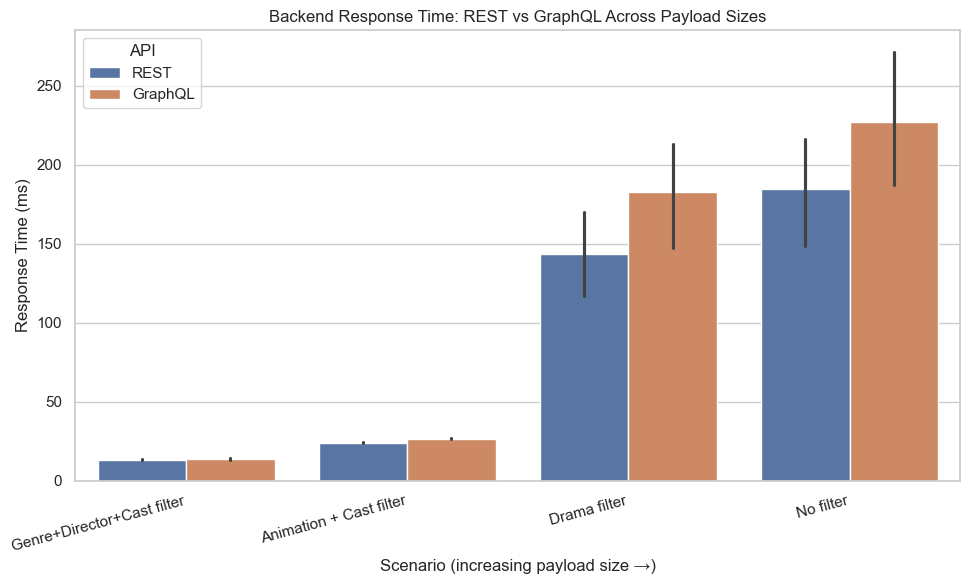

In [33]:
scenario_order = ["Genre+Director+Cast filter", "Animation + Cast filter", "Drama filter", "No filter"]
scenario_order = [s for s in scenario_order if s in clean_backend_df["Scenario"].unique()]

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=clean_backend_df, x="Scenario", y="ResponseTime(ms)", hue="API",
    order=scenario_order, palette=PALETTE, errorbar=("ci", 95), ax=ax,
)
ax.set_title("Backend Response Time: REST vs GraphQL Across Payload Sizes")
ax.set_ylabel("Response Time (ms)")
ax.set_xlabel("Scenario (increasing payload size →)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/response_time_by_scenario.png", dpi=200)
plt.show()

### Response size (data transfer) by configuration and scenario

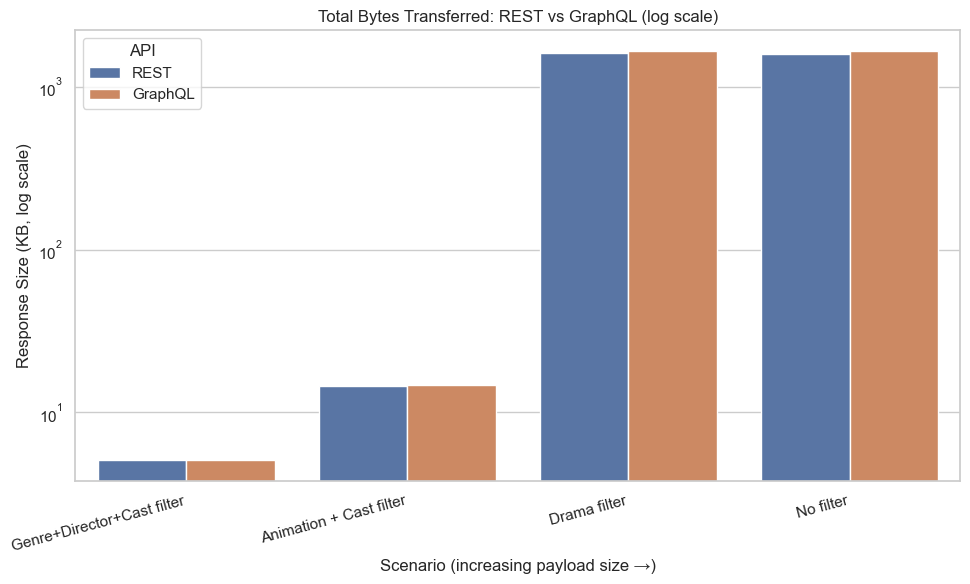

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))
clean_backend_df["ResponseSize(KB)"] = clean_backend_df["ResponseSize(Bytes)"] / 1024
sns.barplot(
    data=clean_backend_df, x="Scenario", y="ResponseSize(KB)", hue="API",
    order=scenario_order, palette=PALETTE, errorbar=None, ax=ax,
)
ax.set_yscale("log")
ax.set_title("Total Bytes Transferred: REST vs GraphQL (log scale)")
ax.set_ylabel("Response Size (KB, log scale)")
ax.set_xlabel("Scenario (increasing payload size →)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/response_size_by_scenario.png", dpi=200)
plt.show()

### FCP and LCP by loading strategy (primary scenario)

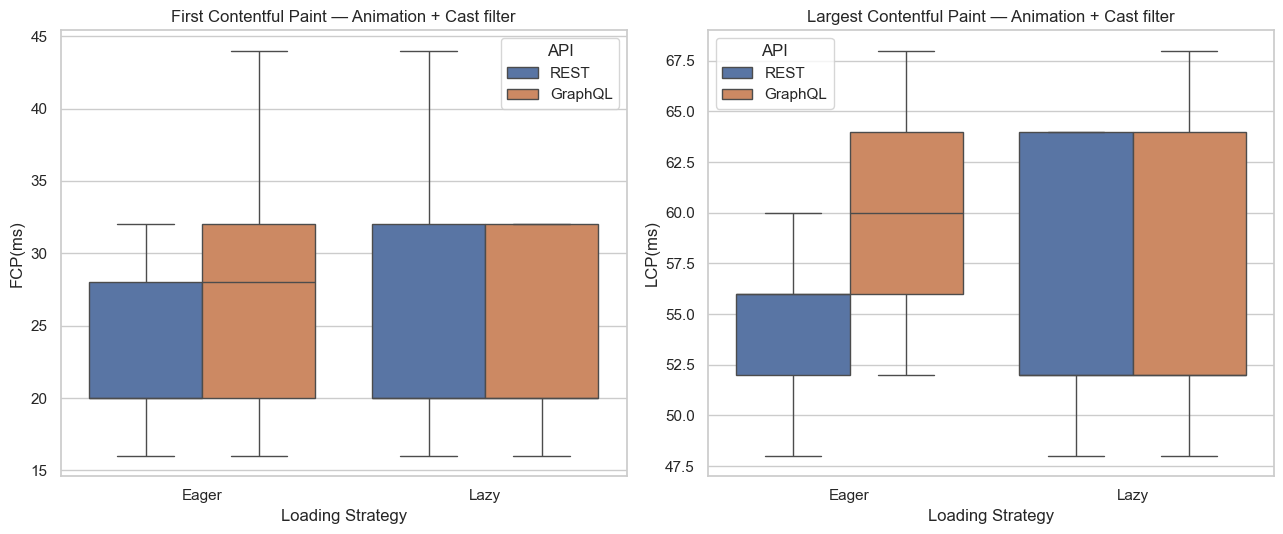

In [35]:
primary_frontend = clean_frontend_df[clean_frontend_df["Scenario"] == PRIMARY_SCENARIO]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, metric, title in zip(
    axes, ["FCP(ms)", "LCP(ms)"],
    ["First Contentful Paint", "Largest Contentful Paint"],
):
    sns.boxplot(
        data=primary_frontend, x="LoadingType", y=metric, hue="API",
        palette=PALETTE, ax=ax,
    )
    ax.set_title(f"{title} — {PRIMARY_SCENARIO}")
    ax.set_xlabel("Loading Strategy")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fcp_lcp_boxplots_primary.png", dpi=200)
plt.show()

### LCP across all four scenarios — testing the Eager/Lazy gap under different payloads

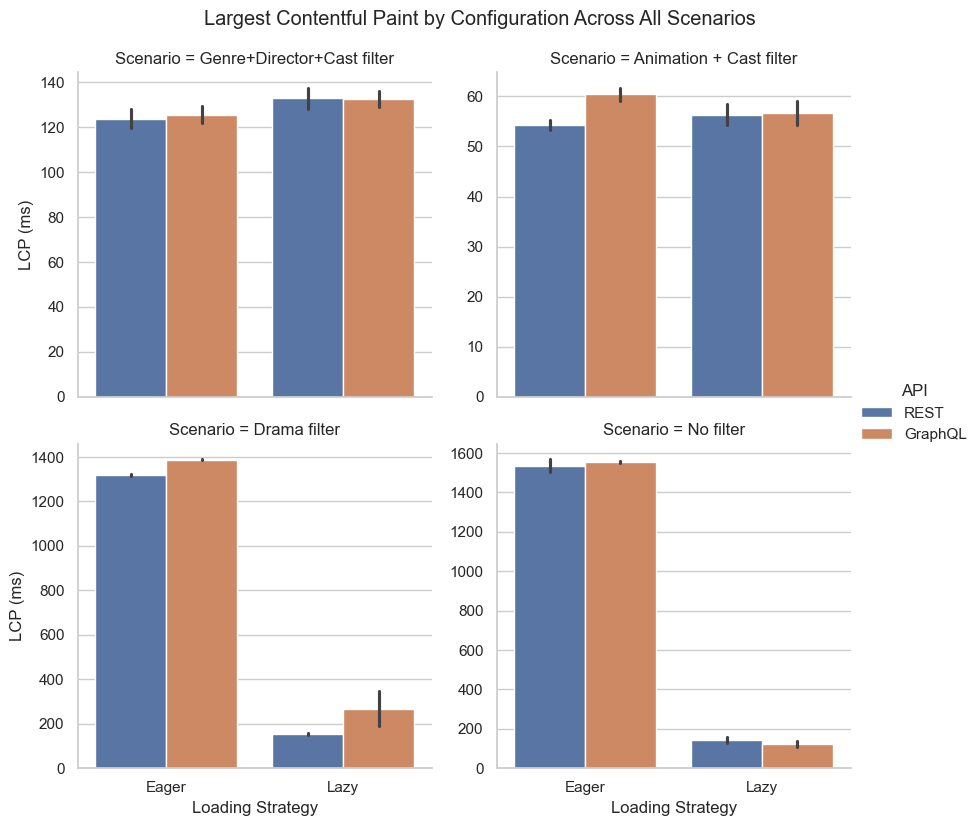

In [36]:
g = sns.catplot(
    data=clean_frontend_df, x="LoadingType", y="LCP(ms)", hue="API",
    col="Scenario", col_order=scenario_order, col_wrap=2,
    kind="bar", palette=PALETTE, errorbar=("ci", 95), height=4, aspect=1.1,
    sharey=False,
)
g.fig.suptitle("Largest Contentful Paint by Configuration Across All Scenarios", y=1.03)
g.set_axis_labels("Loading Strategy", "LCP (ms)")
g.savefig(f"{FIG_DIR}/lcp_all_scenarios.png", dpi=200)
plt.show()

### The 2×2 quadrant summary

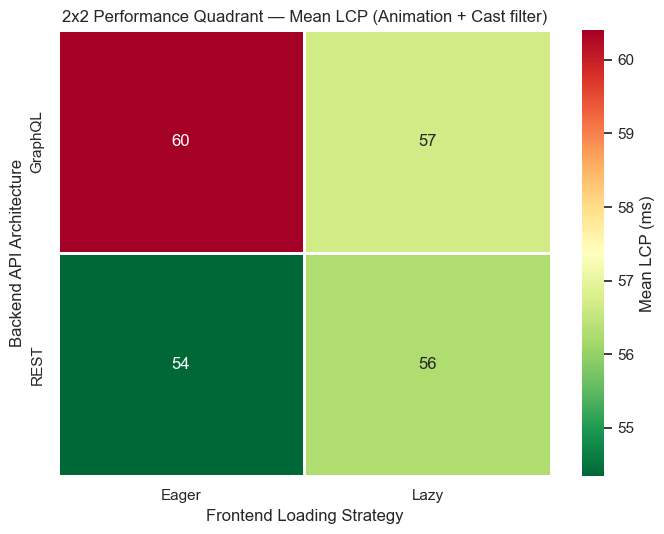

In [37]:
quadrant = (
    clean_frontend_df[clean_frontend_df["Scenario"] == PRIMARY_SCENARIO]
    .groupby(["API", "LoadingType"])["LCP(ms)"]
    .mean()
    .unstack()
    .reindex(index=["GraphQL", "REST"], columns=["Eager", "Lazy"])
)

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(
    quadrant, annot=True, fmt=".0f", cmap="RdYlGn_r", cbar_kws={"label": "Mean LCP (ms)"},
    linewidths=1, linecolor="white", ax=ax,
)
ax.set_title(f"2x2 Performance Quadrant — Mean LCP ({PRIMARY_SCENARIO})")
ax.set_xlabel("Frontend Loading Strategy")
ax.set_ylabel("Backend API Architecture")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/quadrant_heatmap_lcp.png", dpi=200)
plt.show()

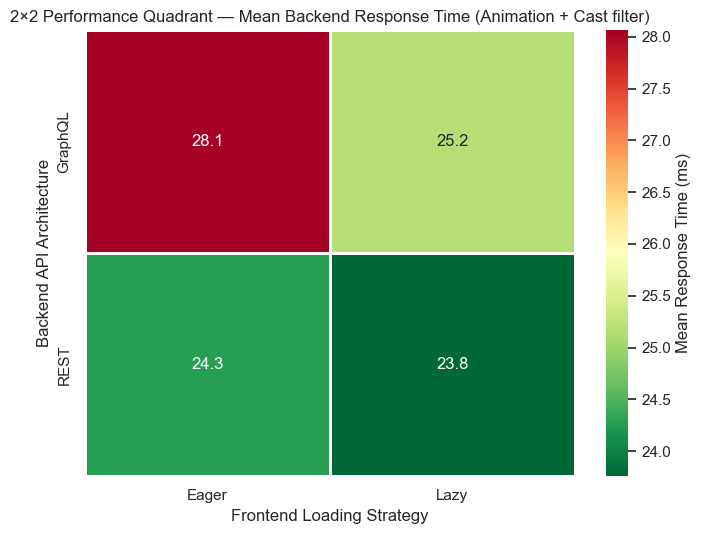

In [38]:
quadrant_rt = (
    clean_backend_df[clean_backend_df["Scenario"] == PRIMARY_SCENARIO]
    .groupby(["API", "LoadingType"])["ResponseTime(ms)"]
    .mean()
    .unstack()
    .reindex(index=["GraphQL", "REST"], columns=["Eager", "Lazy"])
)

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(
    quadrant_rt, annot=True, fmt=".1f", cmap="RdYlGn_r", cbar_kws={"label": "Mean Response Time (ms)"},
    linewidths=1, linecolor="white", ax=ax,
)
ax.set_title(f"2×2 Performance Quadrant — Mean Backend Response Time ({PRIMARY_SCENARIO})")
ax.set_xlabel("Frontend Loading Strategy")
ax.set_ylabel("Backend API Architecture")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/quadrant_heatmap_responsetime.png", dpi=200)
plt.show()